In [1]:
from tqdm import tqdm
import joblib
import pandas as pd
import numpy as np
import requests

import pybaseball as pb

from sklearn.preprocessing import QuantileTransformer

from matplotlib import gridspec
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

In [2]:
pb.cache.enable()

In [ ]:
# s2021 = pb.statcast(start_dt='2021-03-01', end_dt='2021-10-31')
# s2022 = pb.statcast(start_dt='2022-03-01', end_dt='2022-10-31')
# s2023 = pb.statcast(start_dt='2023-03-01', end_dt='2023-10-31')
# s2024 = pb.statcast(start_dt='2024-03-01', end_dt='2024-10-31')
# s2025 = pb.statcast(start_dt='2025-03-01', end_dt='2025-10-31')
# for d in [s2021, s2022, s2023, s2024, s2025]:
#     d.to_csv(f'statcast_{d["year"].iloc[0]}.csv', index=False)

This is a large query, it may take a moment to complete
Skipping offseason dates


100%|██████████| 231/231 [01:27<00:00,  2.65it/s]


In [ ]:
s2021 = pd.read_csv('statcast_2021.csv')
s2022 = pd.read_csv('statcast_2022.csv')
s2023 = pd.read_csv('statcast_2023.csv')
s2024 = pd.read_csv('statcast_2024.csv')
s2025 = pd.read_csv('statcast_2025.csv')

In [8]:
s2026 = pb.statcast(start_dt='2026-03-01', end_dt='2026-10-31')

This is a large query, it may take a moment to complete
Skipping offseason dates


100%|██████████| 231/231 [01:17<00:00,  3.00it/s]


In [9]:
data = pd.concat([s2021,s2022,s2023,s2024,s2025,s2026])

In [10]:
# filter to regular season
data = data.loc[data['game_type'].isin(['R'])].reset_index(drop=True)

# make a month name variable
month_map = {
    3: 'Mar/Apr', 4: 'Mar/Apr',
    5: 'May', 6: 'Jun',
    7: 'Jul', 8: 'Aug',
    9: 'Sep/Oct', 10: 'Sep/Oct',
}
data['game_date'] = pd.to_datetime(data['game_date'])
data['month_number']=data['game_date'].dt.month
data['year']=data['game_date'].dt.year
data['month_name']=data['month_number'].map(month_map)
data['month_name'] = pd.Categorical(data['month_name'], categories=['Mar/Apr','May','Jun','Jul','Aug','Sep/Oct'], ordered=True)
data = data.sort_values(['batter','year','month_name'])

In [11]:
# assuming any bat speed below 50 is a missread/non-competitive
data['bat_speed'] = data['bat_speed'].mask(data['bat_speed'] < 50)

In [12]:
for c in ['launch_speed','release_speed','bat_speed']:
    data[c] = data[c].astype(float)

In [13]:
def get_player_bio(ids):
    data = []
    for pid in tqdm(ids):
        r = requests.get(f'https://statsapi.mlb.com/api/v1/people/{pid}').json()
        if r['people']:
            p = r['people'][0]
            data.append({
                'bam_id': pid,
                'full': p['nameFirstLast'],
                'first': p['useName'],
                'last': p['useLastName'],
                'bats': p['batSide']['code'],
                'position': p['primaryPosition']['abbreviation'],
                'birth_date': p['birthDate'],
                'birthCity': p.get('birthCity'),
                'birthState': p.get('birthStateProvince'),
                'birthCountry': p['birthCountry']
            })
    d = pd.DataFrame(data)
    return d

In [14]:
player_ids = pd.unique(data['batter'])
player_bio = get_player_bio(player_ids)

  0%|          | 0/1587 [00:00<?, ?it/s]

100%|██████████| 1587/1587 [02:35<00:00, 10.23it/s]


In [15]:
pop = data.groupby([
    'batter','month_name','year'
    ]).agg(
        obs = ('pitch_type','count')
    ).reset_index()
pop.head()

,batter,month_name,year,obs
0,405395,Mar/Apr,2021,286
1,405395,Mar/Apr,2022,115
2,405395,May,2021,222
3,405395,May,2022,286
4,405395,Jun,2021,202


In [16]:
# filter to only balls in play for exit velocity data
evd = data.loc[data['description']=='hit_into_play'].reset_index(drop=True)
# filter out bunts
evd['des'] = evd['des'].str.lower()
evd = evd.loc[~evd['des'].str.contains('bunt', na=False)].reset_index(drop=True)
# filter on exit velocity exists
evd = evd.loc[~evd['launch_speed'].isna()].reset_index(drop=True)
# filter out ev above 122.9
evd = evd.loc[evd['launch_speed']<123].reset_index(drop=True)

In [17]:
# calc 90th percentile exit velo
top90 = evd.groupby([
    'batter','month_name','year'
    ]).agg(
        ev90=('launch_speed', lambda x: np.percentile(x, 90)),
        bips=('launch_speed', 'count')
    ).reset_index()
top90.head()

,batter,month_name,year,ev90,bips
0,405395,Mar/Apr,2021,106.16,63
1,405395,Mar/Apr,2022,104.63,24
2,405395,May,2021,108.40,41
3,405395,May,2022,104.10,41
4,405395,Jun,2021,103.90,41


In [18]:
top90['ev90'].describe(percentiles=[.005, .01, .05, .1, .25, .5, .75, .95])

count    15820.000000
mean       101.968335
std          6.321701
min         25.500000
0.5%        69.109500
1%          74.926600
5%          91.820000
10%         96.500000
25%        100.360000
50%        103.040000
75%        105.400000
95%        108.540000
max        117.200000
Name: ev90, dtype: float64

In [19]:
# remove observations where ev90<65
top90['bips'] = np.where(top90['ev90']<65, np.nan, top90['bips'])
top90['ev90'] = np.where(top90['ev90']<65, np.nan, top90['ev90'])

<Axes: >

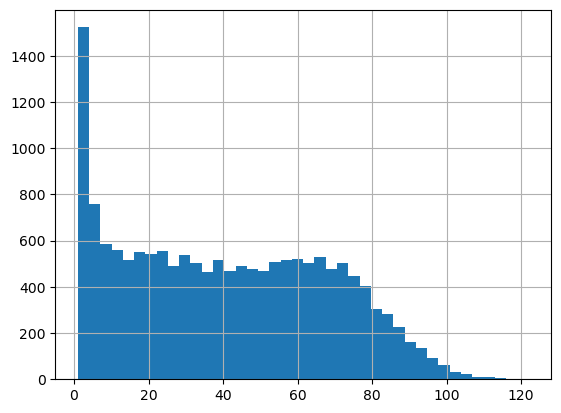

In [20]:
top90['bips'].hist(bins=40)

In [21]:
top90['bips'].describe()

count    15767.000000
mean        40.709710
std         27.109377
min          1.000000
25%         16.000000
50%         39.000000
75%         63.000000
max        122.000000
Name: bips, dtype: float64

In [22]:
# conditional on 90th percentile ev, compute avg pitch velo faced
top = evd.merge(top90, how='left', on=['batter','month_name','year'])
top = top.loc[top['launch_speed'] >= top['ev90']].reset_index(drop=True)
top = top.groupby([
    'batter','month_name','year'
    ]).agg(
        avg_pitch_velocity=('release_speed', 'mean'),
        bips_hard=('launch_speed', 'count')
).reset_index()
top.head(10)

,batter,month_name,year,avg_pitch_velocity,bips_hard
0,405395,Mar/Apr,2021,92.042857,7
1,405395,Mar/Apr,2022,85.033333,3
2,405395,May,2021,91.520000,5
3,405395,May,2022,86.940000,5
4,405395,Jun,2021,84.060000,5
5,405395,Jun,2022,88.733333,3
6,405395,Jul,2021,87.140000,5
7,405395,Jul,2022,92.160000,5
8,405395,Aug,2021,91.350000,2
9,405395,Aug,2022,91.583333,6


In [23]:
top90 = top90.merge(top, on=['batter','month_name','year'], how='left')
top90.head(10)

,batter,month_name,year,ev90,bips,avg_pitch_velocity,bips_hard
0,405395,Mar/Apr,2021,106.16,63.0,92.042857,7.0
1,405395,Mar/Apr,2022,104.63,24.0,85.033333,3.0
2,405395,May,2021,108.40,41.0,91.520000,5.0
3,405395,May,2022,104.10,41.0,86.940000,5.0
4,405395,Jun,2021,103.90,41.0,84.060000,5.0
5,405395,Jun,2022,105.14,29.0,88.733333,3.0
6,405395,Jul,2021,105.79,44.0,87.140000,5.0
7,405395,Jul,2022,107.85,44.0,92.160000,5.0
8,405395,Aug,2021,105.56,19.0,91.350000,2.0
9,405395,Aug,2022,107.26,53.0,91.583333,6.0


In [24]:
pop = pop.merge(top90, on=['batter','month_name','year'], how='left')
pop.head()

,batter,month_name,year,obs,ev90,bips,avg_pitch_velocity,bips_hard
0,405395,Mar/Apr,2021,286,106.16,63.0,92.042857,7.0
1,405395,Mar/Apr,2022,115,104.63,24.0,85.033333,3.0
2,405395,May,2021,222,108.40,41.0,91.520000,5.0
3,405395,May,2022,286,104.10,41.0,86.940000,5.0
4,405395,Jun,2021,202,103.90,41.0,84.060000,5.0


In [25]:
batspeed_data = data.loc[~data['bat_speed'].isna()].reset_index(drop=True)
bsd = batspeed_data.groupby([
    'batter','month_name','year'
    ]).agg(
        bat_speed =('bat_speed', 'mean'),
        bat_speed_sd =('bat_speed', 'std'),
        # bat_speed_025 =('bat_speed', lambda x: np.percentile(x, 2.5)),
        # bat_speed_25 =('bat_speed', lambda x: np.percentile(x, 25)),
        bat_speed_50 =('bat_speed', lambda x: np.percentile(x, 50)),
        # bat_speed_75 =('bat_speed', lambda x: np.percentile(x,75)),
        # bat_speed_975 =('bat_speed', lambda x: np.percentile(x, 97.5)),
        swings=('bat_speed', 'count')
    ).reset_index()
bsd.head()

,batter,month_name,year,bat_speed,bat_speed_sd,bat_speed_50,swings
0,408234,Jul,2023,67.431746,4.122434,67.90,63
1,408234,Aug,2023,67.610526,4.377524,68.15,114
2,408234,Sep/Oct,2023,67.595968,3.991931,67.85,124
3,425794,Sep/Oct,2023,66.280000,3.347686,66.00,5
4,444482,May,2024,69.002703,4.153946,69.90,37


In [26]:
pop = pop.merge(bsd, on=['batter','month_name','year'], how='left')
pop.tail(10)

,batter,month_name,year,obs,ev90,bips,avg_pitch_velocity,bips_hard,bat_speed,bat_speed_sd,bat_speed_50,swings
16258,808982,Sep/Oct,2025,278,102.16,63.0,93.100000,7.0,67.320354,4.294705,68.40,113.0
16259,810938,Mar/Apr,2025,208,105.86,39.0,91.275000,4.0,68.657576,5.589898,69.40,99.0
16260,810938,Mar/Apr,2026,362,101.40,61.0,88.757143,7.0,69.579365,5.243179,70.95,126.0
16261,810938,May,2025,391,104.74,65.0,88.600000,7.0,68.806417,5.318911,69.60,187.0
16262,810938,May,2026,135,105.97,22.0,88.066667,3.0,70.107273,6.417680,70.30,55.0
16263,810938,Jun,2025,302,104.50,46.0,89.500000,6.0,69.335075,5.006541,69.95,134.0
16264,810938,Jul,2025,315,102.00,61.0,92.842857,7.0,67.998496,5.346565,68.30,133.0
16265,814439,May,2026,39,102.04,7.0,90.400000,1.0,73.811111,5.166053,73.05,18.0
16266,823550,May,2026,60,101.04,8.0,94.500000,1.0,70.278261,4.034055,71.30,23.0
16267,829272,Aug,2025,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [27]:
df = pop.merge(player_bio, left_on=['batter'], right_on=['bam_id'], how='left')

In [28]:
df.tail(10)

,batter,month_name,year,obs,ev90,bips,avg_pitch_velocity,bips_hard,bat_speed,bat_speed_sd,...,bam_id,full,first,last,bats,position,birth_date,birthCity,birthState,birthCountry
16258,808982,Sep/Oct,2025,278,102.16,63.0,93.100000,7.0,67.320354,4.294705,...,808982,Jung Hoo Lee,Jung Hoo,Lee,L,RF,1998-08-20,Seoul,NaN,Republic of Korea
16259,810938,Mar/Apr,2025,208,105.86,39.0,91.275000,4.0,68.657576,5.589898,...,810938,Ben Williamson,Ben,Williamson,R,2B,2000-11-05,Fairfax,VA,USA
16260,810938,Mar/Apr,2026,362,101.40,61.0,88.757143,7.0,69.579365,5.243179,...,810938,Ben Williamson,Ben,Williamson,R,2B,2000-11-05,Fairfax,VA,USA
16261,810938,May,2025,391,104.74,65.0,88.600000,7.0,68.806417,5.318911,...,810938,Ben Williamson,Ben,Williamson,R,2B,2000-11-05,Fairfax,VA,USA
16262,810938,May,2026,135,105.97,22.0,88.066667,3.0,70.107273,6.417680,...,810938,Ben Williamson,Ben,Williamson,R,2B,2000-11-05,Fairfax,VA,USA
16263,810938,Jun,2025,302,104.50,46.0,89.500000,6.0,69.335075,5.006541,...,810938,Ben Williamson,Ben,Williamson,R,2B,2000-11-05,Fairfax,VA,USA
16264,810938,Jul,2025,315,102.00,61.0,92.842857,7.0,67.998496,5.346565,...,810938,Ben Williamson,Ben,Williamson,R,2B,2000-11-05,Fairfax,VA,USA
16265,814439,May,2026,39,102.04,7.0,90.400000,1.0,73.811111,5.166053,...,814439,Ryan Waldschmidt,Ryan,Waldschmidt,R,CF,2002-10-07,Sarasota,FL,USA
16266,823550,May,2026,60,101.04,8.0,94.500000,1.0,70.278261,4.034055,...,823550,Sung-Mun Song,Sung-Mun,Song,L,3B,1996-08-29,Seoul,NaN,Republic of Korea
16267,829272,Aug,2025,3,NaN,NaN,NaN,NaN,NaN,NaN,...,829272,Shinnosuke Ogasawara,Shinnosuke,Ogasawara,L,P,1997-10-08,Fujisawa,NaN,Japan


In [29]:
# https://www.baseballprospectus.com/news/article/28956/baseball-therapy-the-one-about-exit-velocity/#:~:text=At%2040%2Dsomething%20balls%20in,to%20come%20in%20the%20season.
MIN_BIPS = 40
MIN_SWINGS = 10

In [30]:
# https://community.fangraphs.com/reverse-engineering-swing-mechanics-from-statcast-data/
df['imputed_bat_speed'] = (df['ev90'] - 0.21*df['avg_pitch_velocity']*(1-.084))/(1+.21)

In [31]:
# remove pitchers and encode a few different postitional groupings
df = df.loc[df['position']!='P'].reset_index(drop=True)
df['position'] = np.where(df['position']=='TWP','DH', df['position'])
df['position_group'] = np.where(df['position'].isin(['DH','1B','3B','LF','RF','OF']),'Power','Defense')
df['position_hybrid'] = np.where(df['position'].isin(['LF','RF','OF']),'COF',df['position'])
df['position_hybrid'] = np.where(df['position'].isin(['1B','3B']),'CINF',df['position_hybrid'])
df['position_hybrid'] = np.where(df['position'].isin(['SS','2B','CF']),'UTM',df['position_hybrid'])

In [32]:
for c in ['ev90', 'bips','avg_pitch_velocity', 'bips_hard', 'bat_speed', 'bat_speed_sd','bat_speed_50','swings','age', 'imputed_bat_speed']:
    try:
        df[c] = df[c].astype(float)
    except KeyError:
        continue

df['is_bip_threshold'] = np.where((df['bips']>=MIN_BIPS), 1, 0) # meets threshold
df['is_swing_threshold'] = np.where((df['swings']>=MIN_SWINGS), 1, 0) # meets threshold
df['is_ev90_na'] = np.where(df['ev90'].isna(), 1, 0) # have no ev90
df['is_bat_speed_na'] = np.where(df['bat_speed'].isna(), 1, 0) # have no bat speed
# remove the instances with no bips and no bat speed
df = df.loc[~((df['is_bat_speed_na']==1) & (df['is_ev90_na']==1))].reset_index(drop=True)

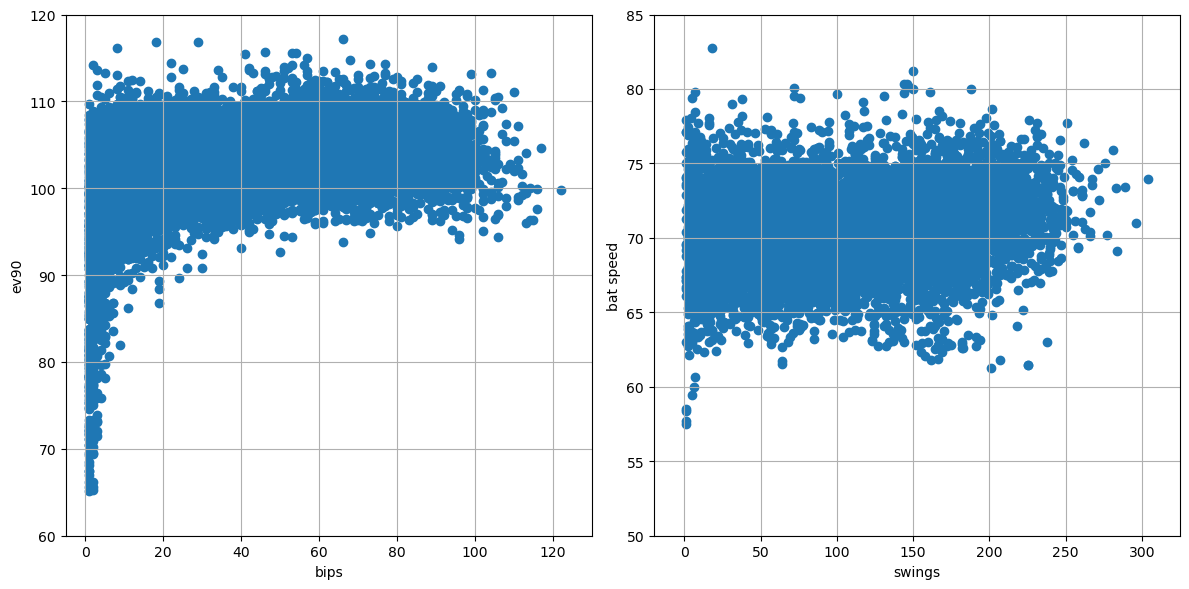

In [75]:
fig, ax = plt.subplots(1, 2, figsize=(12,6))

ax[0].scatter(df['bips'], df['ev90'])
ax[0].set_xlabel('bips')
ax[0].set_ylabel('ev90')
ax[0].set_xlim(-5, 130)
ax[0].set_ylim(60, 120)
ax[0].grid()

ax[1].scatter(df['swings'], df['bat_speed'])
ax[1].set_xlabel('swings')
ax[1].set_ylabel('bat speed')
ax[1].set_xlim(-20, 325)
ax[1].set_ylim(50, 85)
ax[1].grid()
plt.tight_layout()

In [34]:
# complete cases with a bat speed and ev90
df['obs_type'] = np.where((df['is_bat_speed_na']==0)&(df['is_ev90_na']==0),'complete','miss')
# cases with only bat speed
df['obs_type'] = np.where((df['is_bat_speed_na']==0)&(df['is_ev90_na']==1),'batspeed_only', df['obs_type'])
# cases with only ev90
df['obs_type'] = np.where((df['is_bat_speed_na']==1)&(df['is_ev90_na']==0),'ev_only', df['obs_type'])
df['obs_type'].value_counts()

obs_type
complete         7915
ev_only          7176
batspeed_only      61
Name: count, dtype: int64

In [35]:
df['n_type'] = np.where((df['is_bip_threshold']==1)&(df['is_swing_threshold']==1),'complete','incomplete')
df['n_type'] = np.where((df['is_bip_threshold']==0)&(df['is_swing_threshold']==1),'batspeed_only', df['n_type'])
df['n_type'] = np.where((df['is_bip_threshold']==1)&(df['is_swing_threshold']==0),'ev_only', df['n_type'])
df['n_type'].value_counts()

n_type
complete         4077
incomplete       3855
ev_only          3739
batspeed_only    3481
Name: count, dtype: int64

In [36]:
df.loc[(df['n_type']=='batspeed_only')][['swings','bat_speed','bips','ev90']]

,swings,bat_speed,bips,ev90
23,63.0,67.431746,36.0,100.25
84,37.0,69.002703,8.0,98.41
88,98.0,70.406122,37.0,101.22
100,78.0,71.242308,24.0,101.64
127,29.0,72.072414,16.0,103.40
...,...,...,...,...
15139,73.0,67.864384,37.0,98.44
15144,99.0,68.657576,39.0,105.86
15147,55.0,70.107273,22.0,105.97
15150,18.0,73.811111,7.0,102.04


In [37]:
df.loc[(df['n_type']=='incomplete')][['swings','bat_speed','bips','ev90']]

,swings,bat_speed,bips,ev90
1,NaN,NaN,24.0,104.63
5,NaN,NaN,29.0,105.14
8,NaN,NaN,19.0,105.56
10,NaN,NaN,24.0,105.10
12,NaN,NaN,28.0,105.59
...,...,...,...,...
15010,8.0,71.137500,4.0,89.27
15025,5.0,67.760000,3.0,105.68
15035,9.0,71.300000,4.0,106.20
15067,9.0,69.988889,3.0,99.42


In [38]:
df.loc[(df['batter']==689172)][['batter','full','month_name','year','obs','bips','ev90','swings','bat_speed']].sort_values('year')

,batter,full,month_name,year,obs,bips,ev90,swings,bat_speed
14433,689172,Brett Wisely,Mar/Apr,2023,60,10.0,101.47,NaN,NaN
14434,689172,Brett Wisely,May,2023,250,44.0,100.78,NaN,NaN
14437,689172,Brett Wisely,Jun,2023,28,3.0,96.20,NaN,NaN
14440,689172,Brett Wisely,Jul,2023,193,21.0,99.40,59.0,68.503390
14435,689172,Brett Wisely,May,2024,105,23.0,101.36,51.0,68.201961
14438,689172,Brett Wisely,Jun,2024,306,58.0,102.61,123.0,67.314634
14441,689172,Brett Wisely,Jul,2024,268,48.0,99.00,127.0,65.325197
14443,689172,Brett Wisely,Aug,2024,94,20.0,92.56,46.0,67.847826
14444,689172,Brett Wisely,Sep/Oct,2024,208,34.0,101.33,84.0,66.413095
14436,689172,Brett Wisely,May,2025,38,7.0,96.22,21.0,67.776190


In [39]:
df['position'].value_counts()

position
C     2366
LF    2120
1B    2075
3B    1859
RF    1730
2B    1591
SS    1556
CF    1342
DH     258
OF     255
Name: count, dtype: int64

In [40]:
df[['position','position_group']].value_counts()

position  position_group
C         Defense           2366
LF        Power             2120
1B        Power             2075
3B        Power             1859
RF        Power             1730
2B        Defense           1591
SS        Defense           1556
CF        Defense           1342
DH        Power              258
OF        Power              255
Name: count, dtype: int64

In [41]:
df['position_hybrid'].value_counts()

position_hybrid
UTM     4489
COF     4105
CINF    3934
C       2366
DH       258
Name: count, dtype: int64

In [42]:
df[['position','position_hybrid']].value_counts()

position  position_hybrid
C         C                  2366
LF        COF                2120
1B        CINF               2075
3B        CINF               1859
RF        COF                1730
2B        UTM                1591
SS        UTM                1556
CF        UTM                1342
DH        DH                  258
OF        COF                 255
Name: count, dtype: int64

In [43]:
df['birthCountry'].value_counts()

birthCountry
USA                   10040
Dominican Republic     1535
Venezuela              1459
Cuba                    482
Puerto Rico             461
Canada                  208
Mexico                  182
Panama                  127
Colombia                124
Republic of Korea       107
Curacao                  98
Japan                    90
Germany                  54
Aruba                    42
Honduras                 30
Bahamas                  30
Brazil                   21
Taiwan                   18
Australia                17
Netherlands              10
DOM                      10
VEN                       7
Name: count, dtype: int64

In [44]:
df['birthCountry'] = np.where(df['birthCountry'].isin(['DOM']),'Dominican Republic', df['birthCountry'])
df['birthCountry'] = np.where(df['birthCountry'].isin(['VEN']),'Venezuela', df['birthCountry'])
df['region'] = np.where(df['birthCountry'].isin(['Cuba','Mexico','Panama','Colombia','Curacao','Aruba','Honduras','Bahamas','Brazil']),'Latin America', df['birthCountry'])
df['region'] = np.where(df['birthCountry'].isin(['Republic of Korea','Japan','Australia','Taiwan']),'Pacific', df['region'])
df['region'] = np.where(df['birthCountry'].isin(['Netherlands','Germany','Italy']),'Europe', df['region'])
df['region'].value_counts()

region
USA                   10040
Dominican Republic     1545
Venezuela              1466
Latin America          1136
Puerto Rico             461
Pacific                 232
Canada                  208
Europe                   64
Name: count, dtype: int64

In [45]:
df['birthState'].value_counts()

birthState
CA        2486
FL        1102
TX         816
GA         658
NY         446
IL         371
PA         306
VA         284
AZ         269
OH         257
NC         228
MD         197
TN         192
WA         178
NV         176
WI         152
NJ         151
OR         147
MI         139
KY         108
MA         106
MO          96
IN          91
MN          90
AL          89
ON          88
MS          87
CT          84
OK          83
SC          82
LA          81
NE          78
SO          78
QC          78
HI          68
DE          67
NM          59
BC          57
KS          36
CO          36
WY          31
NH          28
IA          23
ID          21
AR          13
UT          11
SI           7
DC           6
ND           5
MT           4
MB           3
Sonora       3
RI           2
NSW          2
QLD          1
Name: count, dtype: int64

In [46]:
# https://en.wikipedia.org/wiki/List_of_regions_of_the_United_States
df['division'] = np.where((df['region']=='USA')&(df['birthState'].isin(['CT','ME','MA','NH','RI','VT'])), 'New England', df['birthState'])
df['division'] = np.where((df['region']=='USA')&(df['birthState'].isin(['NY','NJ','PA'])), 'Mid-Atlantic', df['division'])
df['division'] = np.where((df['region']=='USA')&(df['birthState'].isin(['IL','IN','MI','OH','WI'])), 'East North Central', df['division'])
df['division'] = np.where((df['region']=='USA')&(df['birthState'].isin(['IA','KS','MN','MO','NE','ND','SD'])), 'West North Central', df['division'])
df['division'] = np.where((df['region']=='USA')&(df['birthState'].isin(['GA','NC','SC'])), 'South Atlantic', df['division'])
df['division'] = np.where((df['region']=='USA')&(df['birthState'].isin(['VA','WV'])), 'Virginias', df['division'])
df['division'] = np.where((df['region']=='USA')&(df['birthState'].isin(['DE','DC','MD'])), 'South Mid-Atlantic', df['division'])
df['division'] = np.where((df['region']=='USA')&(df['birthState'].isin(['AL','KY','MS','TN'])), 'East South Central', df['division'])
df['division'] = np.where((df['region']=='USA')&(df['birthState'].isin(['AR','LA','OK','TX'])), 'West South Central', df['division'])
df['division'] = np.where((df['region']=='USA')&(df['birthState'].isin(['AZ','CO','ID','MT','NV','NM','UT','WY'])), 'Mountain', df['division'])
df['division'] = np.where((df['region']=='USA')&(df['birthState'].isin(['AK','HI','OR','WA'])), 'Pacific North West', df['division'])
df['division'] = np.where((df['region']=='USA')&(df['birthState'].isin(['FL'])), 'Florida', df['division'])
df['division'] = np.where((df['region']=='USA')&(df['birthState'].isin(['CA'])), 'California', df['division'])
df['division'].value_counts()

division
California            2486
Florida               1102
East North Central    1010
West South Central     993
South Atlantic         968
Mid-Atlantic           903
Mountain               607
East South Central     476
Pacific North West     393
West North Central     328
Virginias              284
South Mid-Atlantic     270
New England            220
ON                      88
SO                      78
QC                      78
BC                      57
SI                       7
MB                       3
Sonora                   3
NSW                      2
QLD                      1
Name: count, dtype: int64

In [47]:
np.unique(df['birthCity'].loc[df['region']=='Dominican Republic'])

array(['Azua', 'Bajos de Haina', 'Bani', 'Barahona', 'Bayaguana', 'Bonao',
       'Constanza', 'Cotui', 'Esperanza', 'Higuey', 'Juan Baron',
       'La Canela', 'La Romana', 'La Vega', 'Las Matas de Farfan',
       'Las Matas de Santa Cruz', 'Loma de Cabrera', 'Los Llanos',
       'Monte Cristi', 'Monte Plata', 'Montecristi', 'Nagua', 'Nizao',
       'Palenque', 'Puerto Plata', 'Sabana Grande de Boya',
       'Sabana Grande de Palenque', 'Samana', 'San Cristobal',
       'San Francisco De Macoris', 'San Francisco de Macoris', 'San Juan',
       'San Juan de la Maguana', 'San Pedro De Macoris',
       'San Pedro de Macoris', 'Sanchez', 'Santiago',
       'Santiago de los Caballeros', 'Santo Domingo',
       'Santo Domingo Centro', 'Santo Domingo Este',
       'Santo Domingo Oeste', 'Tamboril', 'Tenares'], dtype=object)

In [48]:
df.loc[df['region']=='Venezuela']['birthCity'].value_counts()

birthCity
Maracay                    203
Valencia                   170
Caracas                    150
Maracaibo                  116
Barquisimeto                87
Puerto Ordaz                84
Puerto Cabello              78
Anaco                       43
Los Teques                  37
San Felipe                  32
Guarenas                    30
La Sabana                   28
Naguanagua                  28
Margarita                   27
Bejuma                      25
La Guaira                   25
Caripito                    24
Barcelona                   21
La Victoria                 21
San Carlos                  20
Guatire                     20
La Pica, Maracay            18
Guiria                      18
Valera                      16
El Tigre                    15
San Cristobal               15
Punto Fijo                  14
Tucupita                    13
Carora                      11
Zulia                       10
San Juan                     8
Maturin                      

In [49]:
np.unique(df['birthCity'].loc[df['region']=='Venezuela'])

array(['Acarigua', 'Anaco', 'Araure', 'Barcelona', 'Barinas',
       'Barquisimeto', 'Bejuma', 'Bobures', 'Cabudare', 'Caracas',
       'Caripito', 'Carora', 'Cumana', 'El Tigre', 'El Vigia', 'Guarenas',
       'Guatire', 'Guiria', 'La Guaira', 'La Pica, Maracay', 'La Sabana',
       'La Victoria', 'Libertador de Barinas', 'Los Teques', 'Maracaibo',
       'Maracay', 'Margarita', 'Maturin', 'Montalban', 'Naguanagua',
       'Puerto Cabello', 'Puerto La Cruz', 'Puerto Ordaz', 'Punto Fijo',
       'San Carlos', 'San Cristobal', 'San Cristobal-Tachira',
       'San Felipe', 'San Felix', 'San Fernando de Apure', 'San Juan',
       'Santa Barbara del Zulia', 'Santa Teresa del Tuy', 'Tucupita',
       'Valencia', 'Valera', 'Villa de Cura', 'Villa de Cura, Aragua',
       'Zulia'], dtype=object)

In [50]:
conditions = [
    (df['region']=='Dominican Republic')&(df['birthCity'].str.contains('Santo Domingo', na=False)),
    (df['region']=='Dominican Republic')&(df['birthCity']=='Santiago'),
    (df['region']=='Venezuela')&(df['birthCity'].str.contains('Caracas', na=False)),
    (df['region']=='Venezuela')&(df['birthCity'].str.contains('Maracaibo', na=False)),
    (df['region']=='Venezuela')&(df['birthCity'].str.contains('Valencia', na=False)),
    (df['region']=='Venezuela')&(df['birthCity'].str.contains('Maracay', na=False)),
    (df['region']=='Venezuela')&(df['birthCity'].str.contains('Barquisimeto', na=False)),
]
choices = [
    'Santo Domingo, DR', 
    'Santiago, DR',
    'Caracas, VE',
    'Maracaibo, VE',
    'Valencia, VE',
    'Maracay, VE',
    'Barquisimeto, VE'
]
df['country'] = np.select(conditions, choices, default=df['region'])
df['country'] = np.where(df['region']=='USA', df['division']+', USA', df['country'])
df['country'].value_counts()

country
California, USA            2486
Latin America              1136
Florida, USA               1102
East North Central, USA    1010
West South Central, USA     993
South Atlantic, USA         968
Mid-Atlantic, USA           903
Dominican Republic          884
Venezuela                   722
Mountain, USA               607
Santo Domingo, DR           546
East South Central, USA     476
Puerto Rico                 461
Pacific North West, USA     393
West North Central, USA     328
Virginias, USA              284
South Mid-Atlantic, USA     270
Pacific                     232
Maracay, VE                 221
New England, USA            220
Canada                      208
Valencia, VE                170
Caracas, VE                 150
Maracaibo, VE               116
Santiago, DR                115
Barquisimeto, VE             87
Europe                       64
Name: count, dtype: int64

In [51]:
df['country2'] = np.where(df['region']=='USA', df['division']+', USA', df['region'])
df['country2'].value_counts()

country2
California, USA            2486
Dominican Republic         1545
Venezuela                  1466
Latin America              1136
Florida, USA               1102
East North Central, USA    1010
West South Central, USA     993
South Atlantic, USA         968
Mid-Atlantic, USA           903
Mountain, USA               607
East South Central, USA     476
Puerto Rico                 461
Pacific North West, USA     393
West North Central, USA     328
Virginias, USA              284
South Mid-Atlantic, USA     270
Pacific                     232
New England, USA            220
Canada                      208
Europe                       64
Name: count, dtype: int64

<Axes: >

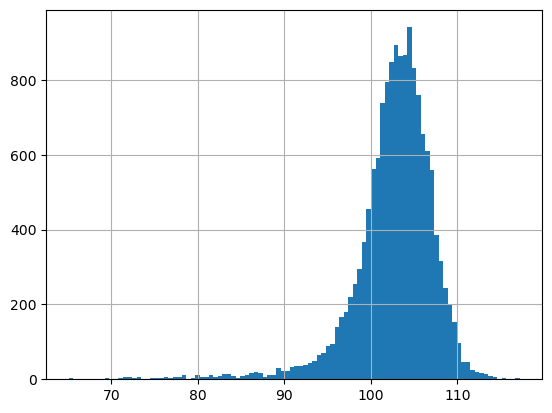

In [52]:
df['ev90'].hist(bins=100)

<Axes: >

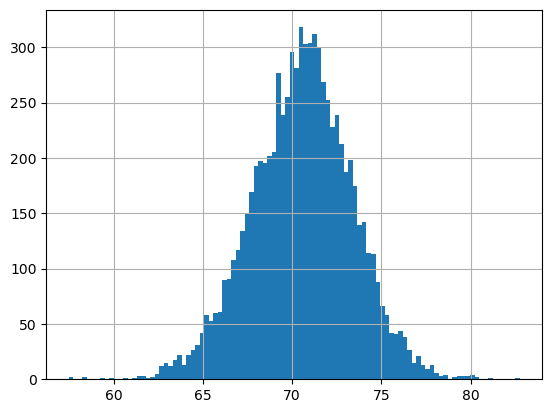

In [53]:
df['bat_speed'].hist(bins=100)

In [54]:
df['ev90_center'] = df['ev90'] - df['ev90'].mean()
df['bat_speed_center'] = df['bat_speed'] - df['bat_speed'].mean()
df['imputed_bat_speed_center'] = df['imputed_bat_speed'] - df['imputed_bat_speed'].mean()

df['ev90_z'] =  df['ev90_center']/ df['ev90'].std()
df['bat_speed_z'] =  df['bat_speed_center']/ df['bat_speed'].std()
df['imputed_bat_speed_z'] =  df['imputed_bat_speed_center']/ df['imputed_bat_speed_center'].std()

In [55]:
df = df.reset_index(drop=True)
qt = QuantileTransformer(random_state=0, output_distribution="normal")
qt_values = pd.DataFrame(qt.fit_transform(df[['ev90','bat_speed','imputed_bat_speed']]), columns=['ev90_qt','bat_speed_qt','imputed_bat_speed_qt'])
df = pd.concat([df, qt_values], axis=1)

<Axes: >

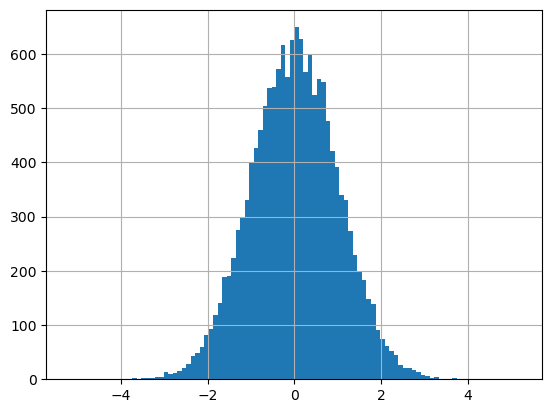

In [56]:
df['ev90_qt'].hist(bins=100)

<Axes: >

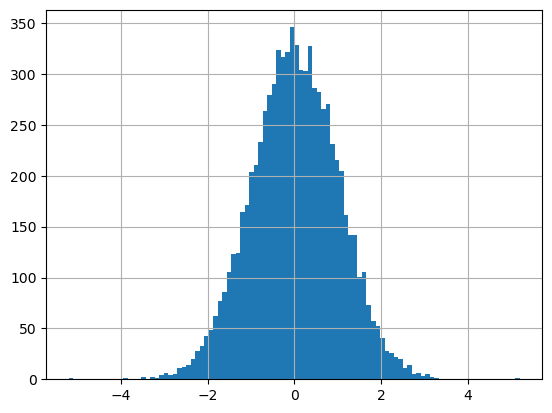

In [57]:
df['bat_speed_qt'].hist(bins=100)

In [58]:
joblib.dump(qt, 'quantile_scaler.pkl')

['quantile_scaler.pkl']

In [59]:
df.columns

Index(['batter', 'month_name', 'year', 'obs', 'ev90', 'bips',
       'avg_pitch_velocity', 'bips_hard', 'bat_speed', 'bat_speed_sd',
       'bat_speed_50', 'swings', 'bam_id', 'full', 'first', 'last', 'bats',
       'position', 'birth_date', 'birthCity', 'birthState', 'birthCountry',
       'imputed_bat_speed', 'position_group', 'position_hybrid',
       'is_bip_threshold', 'is_swing_threshold', 'is_ev90_na',
       'is_bat_speed_na', 'obs_type', 'n_type', 'region', 'division',
       'country', 'country2', 'ev90_center', 'bat_speed_center',
       'imputed_bat_speed_center', 'ev90_z', 'bat_speed_z',
       'imputed_bat_speed_z', 'ev90_qt', 'bat_speed_qt',
       'imputed_bat_speed_qt'],
      dtype='str')

In [60]:
debut = df.dropna(subset=['ev90']).groupby('bam_id')['year'].min().reset_index().rename(columns={'year':'debut_year'})
debut.head()

,bam_id,debut_year
0,405395,2021
1,408234,2021
2,425772,2021
3,425784,2021
4,425877,2021


In [61]:
seasons = sorted(pd.unique(df['year']))
months = df['month_name'].cat.categories
year_month_index = pd.MultiIndex.from_product([seasons, months], names=['year','month_name']).to_frame(index=False).reset_index(drop=False).rename(columns={'index': 'time_index'})

grid_rows = []
for _, row in debut.iterrows():
    for season in [s for s in pd.unique(df['year']) if s >= row['debut_year']]:
        for month in pd.unique(df['month_name']):
            grid_rows.append({
                'bam_id': row['bam_id'],
                'year': season,
                'month_name': month
            })

grid = pd.DataFrame(grid_rows)
grid_shape = grid.shape[0]

grid = grid.merge(year_month_index, on=['year','month_name'], how='left')

subset_df = df[[
    'bam_id','month_name','year',
    'bips','ev90','ev90_center','ev90_z','ev90_qt',
    'imputed_bat_speed','imputed_bat_speed_center','imputed_bat_speed_z','imputed_bat_speed_qt',
    'swings','bat_speed','bat_speed_center','bat_speed_z','bat_speed_qt',
    'obs_type','n_type'
    ]]
grid = grid.merge(subset_df, on=['bam_id','month_name','year'], how='left')
assert grid.shape[0] == grid_shape

# bio data
bio_subset = df[[
    'bam_id','full','first','last','bats',
    'birth_date',
    'position','position_group','position_hybrid',
    'region','country','country2',
]].drop_duplicates(['bam_id'])
grid = grid.merge(bio_subset, on=['bam_id'], how='left')

grid['month_name'] = pd.Categorical(grid['month_name'], categories=['Mar/Apr','May','Jun','Jul','Aug','Sep/Oct'], ordered=True)

assert grid.shape[0] == grid_shape

In [62]:
grid.sort_values(['bam_id','year','month_name']).head(10)

,bam_id,year,month_name,time_index,bips,ev90,ev90_center,ev90_z,ev90_qt,imputed_bat_speed,...,first,last,bats,birth_date,position,position_group,position_hybrid,region,country,country2
0,405395,2021,Mar/Apr,0,63.0,106.16,3.538975,0.734768,0.892038,73.103005,...,Albert,Pujols,R,1980-01-16,1B,Power,CINF,Dominican Republic,"Santo Domingo, DR",Dominican Republic
1,405395,2021,May,1,41.0,108.40,5.778975,1.199840,1.588771,75.037366,...,Albert,Pujols,R,1980-01-16,1B,Power,CINF,Dominican Republic,"Santo Domingo, DR",Dominican Republic
2,405395,2021,Jun,2,41.0,103.90,1.278975,0.265543,0.205941,72.504313,...,Albert,Pujols,R,1980-01-16,1B,Power,CINF,Dominican Republic,"Santo Domingo, DR",Dominican Republic
3,405395,2021,Jul,3,44.0,105.79,3.168975,0.657948,0.783330,73.576653,...,Albert,Pujols,R,1980-01-16,1B,Power,CINF,Dominican Republic,"Santo Domingo, DR",Dominican Republic
4,405395,2021,Aug,4,19.0,105.56,2.938975,0.610195,0.711981,72.717284,...,Albert,Pujols,R,1980-01-16,1B,Power,CINF,Dominican Republic,"Santo Domingo, DR",Dominican Republic
5,405395,2021,Sep/Oct,5,24.0,105.10,2.478975,0.514689,0.577557,73.187636,...,Albert,Pujols,R,1980-01-16,1B,Power,CINF,Dominican Republic,"Santo Domingo, DR",Dominican Republic
6,405395,2022,Mar/Apr,6,24.0,104.63,2.008975,0.417107,0.430727,72.952883,...,Albert,Pujols,R,1980-01-16,1B,Power,CINF,Dominican Republic,"Santo Domingo, DR",Dominican Republic
7,405395,2022,May,7,41.0,104.10,1.478975,0.307067,0.265284,72.211753,...,Albert,Pujols,R,1980-01-16,1B,Power,CINF,Dominican Republic,"Santo Domingo, DR",Dominican Republic
8,405395,2022,Jun,8,29.0,105.14,2.518975,0.522994,0.589456,72.786162,...,Albert,Pujols,R,1980-01-16,1B,Power,CINF,Dominican Republic,"Santo Domingo, DR",Dominican Republic
9,405395,2022,Jul,9,44.0,107.85,5.228975,1.085648,1.421556,74.481076,...,Albert,Pujols,R,1980-01-16,1B,Power,CINF,Dominican Republic,"Santo Domingo, DR",Dominican Republic


In [63]:
month_map_num = {
    'Mar/Apr': 4, 'May': 5, 'Jun': 6, 
    'Jul': 7, 'Aug': 8, 'Sep/Oct': 9
}
def get_age(row):
    bday = pd.to_datetime(row['birth_date'])
    ref_year = int(row['year'])
    ref_month = month_map_num.get(row['month_name'])
    ref_date = pd.Timestamp(year=ref_year, month=ref_month, day=15)
    days_diff = (ref_date - bday).days
    age = days_diff/365.25
    return age

In [64]:
grid['age'] = grid.apply(get_age, axis=1)

In [65]:
grid['age'].describe()

count    34650.000000
mean        29.585751
std          4.180760
min         19.778234
25%         26.546201
50%         29.125257
75%         32.191650
max         46.663929
Name: age, dtype: float64

In [66]:
grid.loc[grid['age']<20][['birth_date','full','month_name','year','age']].sort_values(['age','year','month_name'])

,birth_date,full,month_name,year,age
33294,2003-07-05,Junior Caminero,Mar/Apr,2023,19.778234
33295,2003-07-05,Junior Caminero,May,2023,19.860370
33296,2003-07-05,Junior Caminero,Jun,2023,19.945243
34416,2006-04-24,Konnor Griffin,Mar/Apr,2026,19.975359


<Axes: >

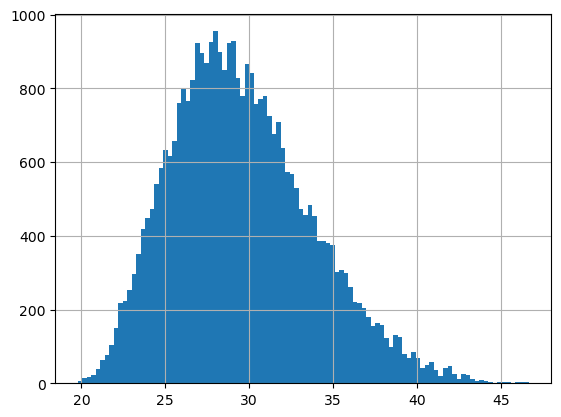

In [67]:
grid['age'].hist(bins=100)

In [68]:
grid['age_center'] = grid['age'] - grid['age'].mean()
grid['age_z'] = grid['age_center']/ grid['age'].std()

In [69]:
grid = grid.reset_index(drop=True)
qt_age = QuantileTransformer(random_state=0, output_distribution="normal")
qt_values = pd.DataFrame(qt_age.fit_transform(grid[['age']]), columns=['age_qt'])
grid = pd.concat([grid, qt_values], axis=1)

<Axes: >

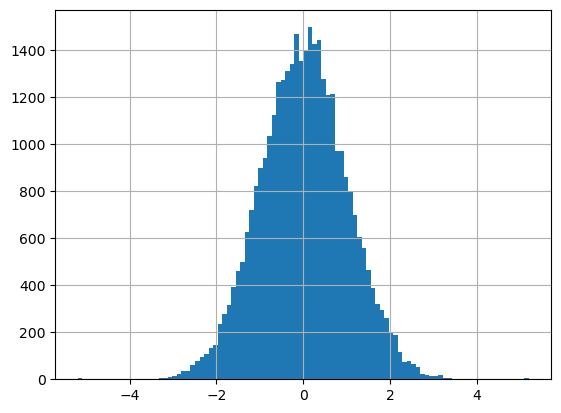

In [70]:
grid['age_qt'].hist(bins=100)

In [71]:
joblib.dump(qt_age, 'quantile_age.pkl')

['quantile_age.pkl']

In [72]:
grid.to_csv('data.csv',index=False)

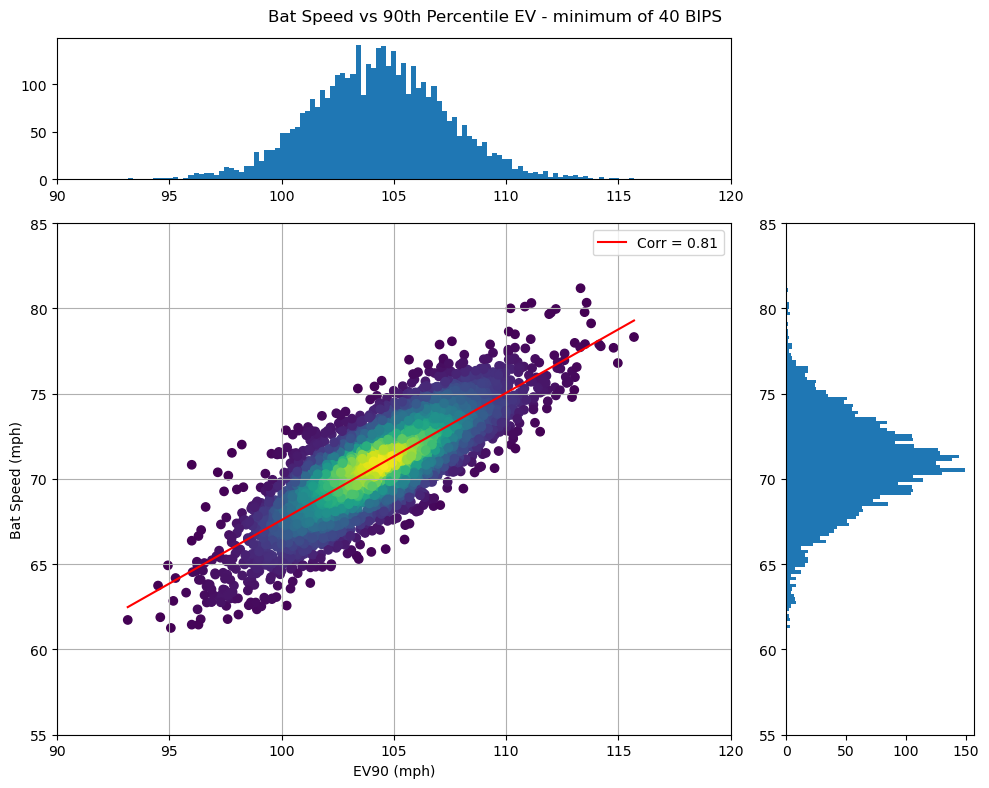

In [73]:
# Bat Speed and EV90
cd = grid.dropna(subset=['bat_speed', 'ev90']).copy()
cd = cd.loc[cd['bips']>=MIN_BIPS]
x = cd['ev90'].values.astype(float)
y = cd['bat_speed'].values.astype(float)

xy = np.vstack([x, y])
kde_joint = gaussian_kde(xy)
density = kde_joint(xy)

x_grid = np.linspace(x.min(), x.max(), 200)
y_grid = np.linspace(y.min(), y.max(), 200)

fig = plt.figure(figsize=(10, 8))
gs = gridspec.GridSpec(4, 4)

ax_joint = fig.add_subplot(gs[1:4, 0:3])
ax_marg_x = fig.add_subplot(gs[0, 0:3], sharex = ax_joint)
ax_marg_y = fig.add_subplot(gs[1:4, 3], sharey = ax_joint)

sc = ax_joint.scatter(x, y, c=density, cmap='viridis')
m, b = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 100)
ax_joint.plot(x_line, m * x_line + b, color='red', label=f'Corr = {np.corrcoef(x,y)[0,1]:.2f}')
ax_joint.set_xticks(np.arange(90, 121, 5)) 
ax_joint.set_yticks(np.arange(55, 86, 5))
ax_joint.set_xlim(90, 120)
ax_joint.set_ylim(55, 85)
ax_joint.grid(True)

ax_joint.set_xlabel('EV90 (mph)')
ax_joint.set_ylabel('Bat Speed (mph)')
ax_joint.legend()

ax_marg_x.hist(x,bins=100)
ax_marg_y.hist(y,bins=100, orientation='horizontal')

fig.suptitle(f'Bat Speed vs 90th Percentile EV - minimum of {MIN_BIPS} BIPS''')
plt.tight_layout()

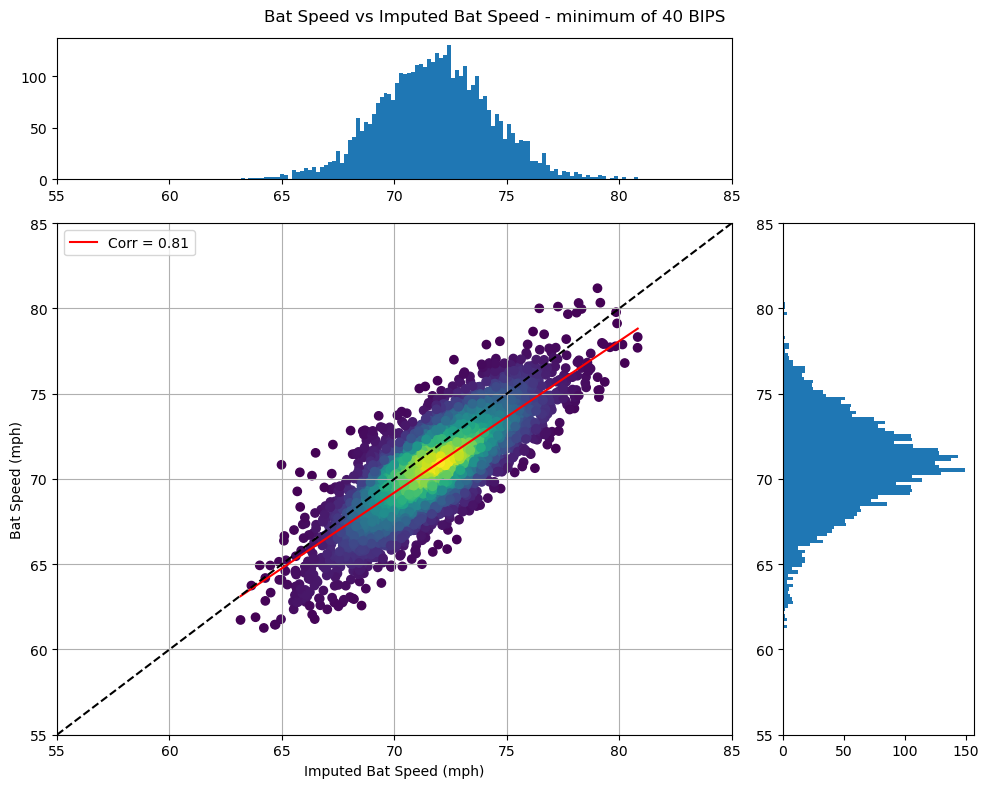

In [74]:
# Bat Speed and Imputed Bat Speed
cd = grid.dropna(subset=['bat_speed', 'imputed_bat_speed']).copy()
cd = cd.loc[cd['bips']>=MIN_BIPS]
x = cd['imputed_bat_speed'].values.astype(float)
y = cd['bat_speed'].values.astype(float)

xy = np.vstack([x, y])
kde_joint = gaussian_kde(xy)
density = kde_joint(xy)

x_grid = np.linspace(x.min(), x.max(), 200)
y_grid = np.linspace(y.min(), y.max(), 200)

fig = plt.figure(figsize=(10, 8))
gs = gridspec.GridSpec(4, 4)

ax_joint = fig.add_subplot(gs[1:4, 0:3])
ax_marg_x = fig.add_subplot(gs[0, 0:3], sharex = ax_joint)
ax_marg_y = fig.add_subplot(gs[1:4, 3], sharey = ax_joint)

sc = ax_joint.scatter(x, y, c=density, cmap='viridis')
m, b = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 100)
ax_joint.plot(x_line, m * x_line + b, color='red', label=f'Corr = {np.corrcoef(x,y)[0,1]:.2f}')
ax_joint.axline((0, 0), slope=1, color='black', linestyle='--')
ax_joint.set_xticks(np.arange(55, 86, 5))
ax_joint.set_yticks(np.arange(55, 86, 5))
ax_joint.set_xlim(55, 85)
ax_joint.set_ylim(55, 85)
ax_joint.grid(True)

ax_joint.set_xlabel('Imputed Bat Speed (mph)')
ax_joint.set_ylabel('Bat Speed (mph)')
ax_joint.legend()

ax_marg_x.hist(x,bins=100)
ax_marg_y.hist(y,bins=100, orientation='horizontal')

fig.suptitle(f'Bat Speed vs Imputed Bat Speed - minimum of {MIN_BIPS} BIPS''')
plt.tight_layout()